# 6. Application

The final Random Forest model will be integrated into an interactive application that allows users to estimate flight prices from flight characteristics.

Before building the interface, the trained model will be prepared for deployment and tested independently from the training notebook.

In [10]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt



In [4]:

model_path = Path("random_forest_flight_price_model.pkl")

size_gb = model_path.stat().st_size / (1024 ** 3)

print(f"Model size: {size_gb:.2f} GB")

Model size: 1.17 GB


In [5]:

# Load the trained model
model = joblib.load("random_forest_flight_price_model.pkl")

# Save a compressed version
joblib.dump(
    model,
    "random_forest_flight_price_model_compressed.pkl",
    compress=3
)

print("Compressed model saved.")

Compressed model saved.


In [6]:
model_path = Path("random_forest_flight_price_model_compressed.pkl")

size_mb = model_path.stat().st_size / (1024 ** 2)

print(f"Compressed model size: {size_mb:.2f} MB")

Compressed model size: 221.04 MB


## 6.1 Loading the Final Model

The compressed Random Forest pipeline will be loaded into the application environment.

The pipeline contains both the preprocessing steps and the trained model, allowing new flight characteristics to be passed directly to the model without repeating the feature engineering process.

In [ ]:

model = joblib.load(
    "random_forest_flight_price_model_compressed.pkl"
)

print("Final model loaded successfully.")

Final model loaded successfully.


### 6.2 Prediction Function

A prediction function will be created to receive the characteristics of a flight and return the price estimated by the trained Random Forest model.

The function uses the complete pipeline, including the preprocessing steps learned during training, so new observations can be passed directly to the model.

The application will not only estimate the price of a specific flight, but also evaluate different booking lead times.

By changing `days_left` while keeping the other flight characteristics constant, we can estimate how the predicted price changes as the departure date approaches.

The lowest predicted price will be used to identify the model's estimated best booking window.


In [ ]:

def predict_price(
    airline,
    source_airport,
    destination_airport,
    travel_date,
    stops,
    duration_minutes,
    departure_time
):
    
    # Convert travel date to datetime
    travel_date = pd.to_datetime(travel_date)
    
    # Calculate days left until departure
    today = pd.Timestamp.today().normalize()
    days_left = (travel_date - today).days
    
    # Calculate departure day of the week
    departure_day_of_week = travel_date.day_name().lower()
    
    # Calculate departure daypart
    hour = int(departure_time.split(":")[0])
    
    if hour < 6:
        departure_daypart = "night"
    elif hour < 12:
        departure_daypart = "morning"
    elif hour < 18:
        departure_daypart = "afternoon"
    else:
        departure_daypart = "evening"
    
    # Create input DataFrame
    flight = pd.DataFrame({
        "airline": [airline],
        "source_airport": [source_airport],
        "destination_airport": [destination_airport],
        "stops": [stops],
        "days_left": [days_left],
        "departure_daypart": [departure_daypart],
        "departure_day_of_week": [departure_day_of_week],
        "duration_minutes": [duration_minutes]
    })
    
    # Predict price
    prediction = model.predict(flight)
    
    return prediction[0]


### 6.3 Best Booking Window

The application will evaluate several booking lead times for the same flight.

By varying `days_left` while keeping the other flight characteristics constant, we can compare the model's estimated prices and identify the booking window with the lowest predicted price.

This is a scenario analysis based on the model's predictions, not a guarantee of future prices.

In [16]:
# Define a function to analyze the booking window for a given flight
def booking_window_analysis(
    airline,
    source_airport,
    destination_airport,
    travel_date,
    stops,
    duration_minutes,
    departure_time
):
    
    # Convert travel date to datetime
    travel_date = pd.to_datetime(travel_date)
    
    # Calculate how many days remain until departure
    today = pd.Timestamp.today().normalize()
    current_days_left = (travel_date - today).days
    
    # Check that the flight is in the future
    if current_days_left <= 0:
        raise ValueError("Travel date must be in the future.")
    
    # Evaluate from 1 day before departure
    # up to 180 days before departure,
    # but never beyond the current booking window
    max_days = min(current_days_left, 180)
    
    booking_days = list(range(1, max_days + 1))
    
    # Calculate departure day of the week
    departure_day_of_week = travel_date.day_name().lower()
    
    # Calculate departure daypart
    hour = int(departure_time.split(":")[0])
    
    if hour < 6:
        departure_daypart = "night"
    elif hour < 12:
        departure_daypart = "morning"
    elif hour < 18:
        departure_daypart = "afternoon"
    else:
        departure_daypart = "evening"
    
    # Create one row for each booking scenario
    flights = pd.DataFrame({
        "airline": [airline] * len(booking_days),
        "source_airport": [source_airport] * len(booking_days),
        "destination_airport": [destination_airport] * len(booking_days),
        "stops": [stops] * len(booking_days),
        "days_left": booking_days,
        "departure_daypart": [departure_daypart] * len(booking_days),
        "departure_day_of_week": [departure_day_of_week] * len(booking_days),
        "duration_minutes": [duration_minutes] * len(booking_days)
    })
    
    # Predict all scenarios
    predictions = model.predict(flights)
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        "days_left": booking_days,
        "predicted_price": predictions
    })
    
    # Find the minimum predicted price
    best_index = results_df["predicted_price"].idxmin()
    best_row = results_df.loc[best_index]
    
    # Find the prediction for the current booking date
    today_prediction = results_df[
        results_df["days_left"] == current_days_left
    ]
    
    if not today_prediction.empty:
        current_price = today_prediction["predicted_price"].iloc[0]
    else:
        current_price = None
    
    return results_df, best_row, current_days_left, current_price

In [18]:
# Example usage of the booking_window_analysis function
results, best, current_days, current_price = booking_window_analysis(
    airline="Vueling",
    source_airport="BCN",
    destination_airport="FCO",
    travel_date="2027-07-15",
    stops=0,
    duration_minutes=120,
    departure_time="10:00"
)

print(f"Days left until departure: {current_days}")

if current_price is not None:
    print(f"Estimated price if booked today: €{current_price:.2f}")
else:
    print("Estimated price today: outside the 180-day analysis window")

print(
    f"Best booking window: "
    f"{int(best['days_left'])} days before departure"
)

print(
    f"Best estimated price: "
    f"€{best['predicted_price']:.2f}"
)

Days left until departure: 331
Estimated price today: outside the 180-day analysis window
Best booking window: 54 days before departure
Best estimated price: €69.34


In [20]:
# Calculate potential price difference from the best estimated price

best_price = best["predicted_price"]

results["difference_from_best"] = (
    results["predicted_price"] - best_price
)

print(results.head())

   days_left  predicted_price  difference_from_best
0          1       190.560333            121.223667
1          2       193.093333            123.756667
2          3       193.175833            123.839167
3          4       189.921500            120.584833
4          5       189.533500            120.196833


### 6.7 Booking Window Visualization

The booking window analysis is visualized to show how the model's predicted price changes depending on the number of days remaining before departure.

The minimum predicted price is highlighted to make the recommended booking point easy to identify.

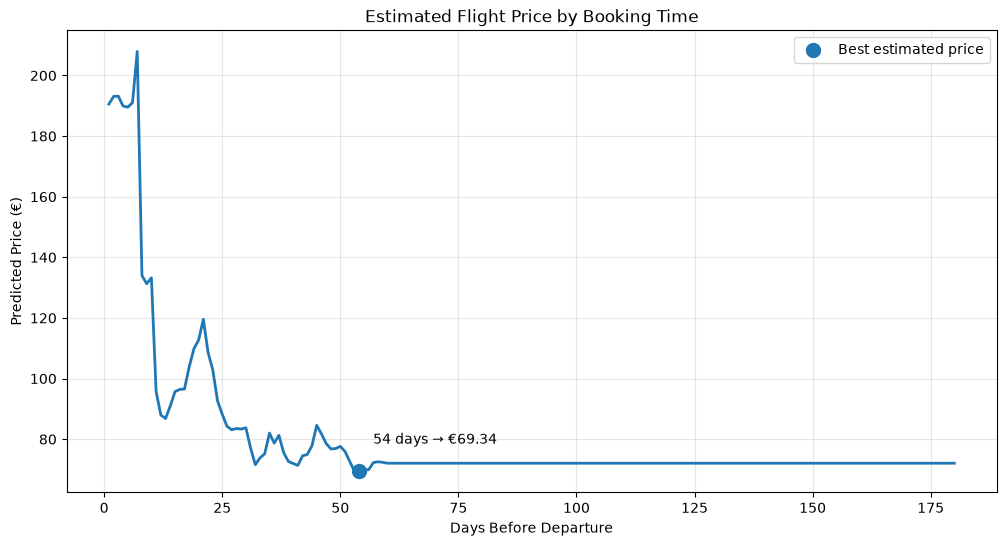

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    results["days_left"],
    results["predicted_price"],
    linewidth=2
)

plt.scatter(
    best["days_left"],
    best["predicted_price"],
    s=100,
    zorder=5,
    label="Best estimated price"
)

plt.annotate(
    f"{int(best['days_left'])} days → €{best['predicted_price']:.2f}",
    xy=(best["days_left"], best["predicted_price"]),
    xytext=(10, 20),
    textcoords="offset points"
)

plt.xlabel("Days Before Departure")
plt.ylabel("Predicted Price (€)")
plt.title("Estimated Flight Price by Booking Time")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 7. Streamlit Application

The trained Random Forest model and booking window analysis will be integrated into an interactive Streamlit application.

The application will allow users to enter flight characteristics and receive an estimated flight price together with a recommended booking window.